Noorin Nashika - 24BAD084
Decision Tree Accuracy: 1.0
Bagging Accuracy: 1.0


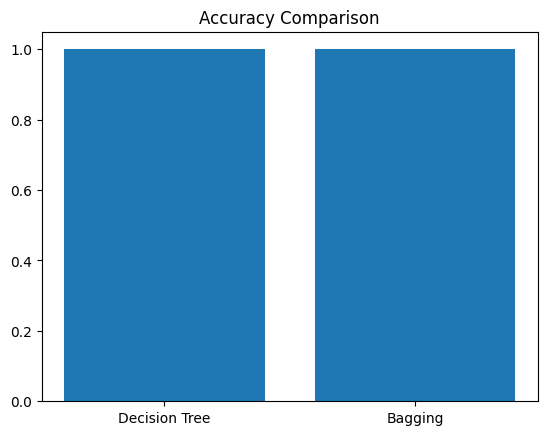

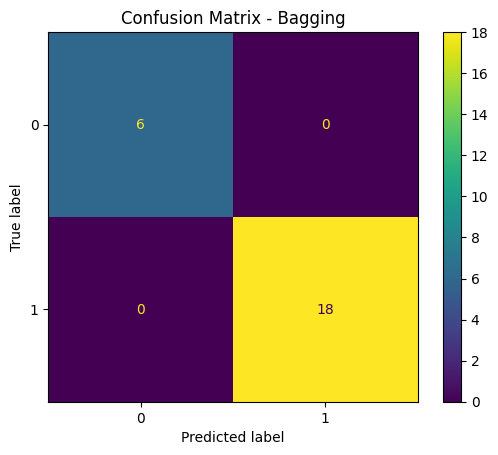

In [3]:
#from google.colab import files
#uploaded = files.upload()
# SCENARIO 1: BAGGING
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
print("Noorin Nashika - 24BAD084")
# Load dataset
df = pd.read_csv("diabetes_bagging.csv")

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# Bagging
bag = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50, random_state=42)
bag.fit(X_train, y_train)
y_pred_bag = bag.predict(X_test)

# Accuracy
acc_dt = accuracy_score(y_test, y_pred_dt)
acc_bag = accuracy_score(y_test, y_pred_bag)
print("Decision Tree Accuracy:", acc_dt)
print("Bagging Accuracy:", acc_bag)

# Visualization - Accuracy
plt.bar(["Decision Tree", "Bagging"], [acc_dt, acc_bag])
plt.title("Accuracy Comparison")
plt.show()
# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_bag)
plt.title("Confusion Matrix - Bagging")
plt.show()

Saving churn_boosting.csv to churn_boosting (1).csv
Noorin Nashika M - 24BAD084
Boosting Models - Customer Churn Prediction

First 5 rows:
    Tenure  MonthlyCharges    ContractType InternetService  Churn
0      65          105.22        Two year             NaN      0
1      17           75.19  Month-to-month             NaN      0
2      71           76.09        Two year     Fiber optic      0
3      45          107.67        Two year     Fiber optic      0
4       4           60.35        Two year             NaN      0

Model Accuracy:
AdaBoost Accuracy: 1.0000
Gradient Boosting Accuracy: 1.0000


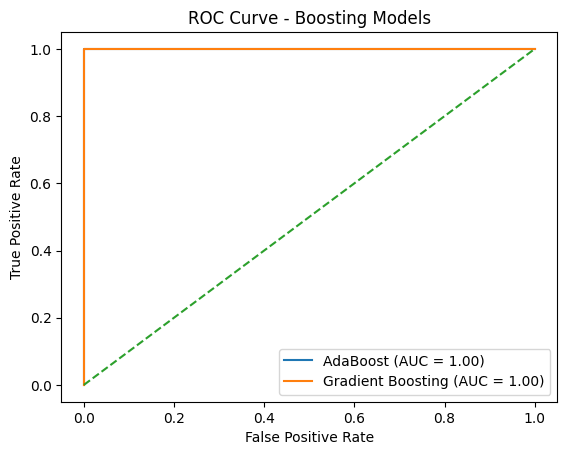

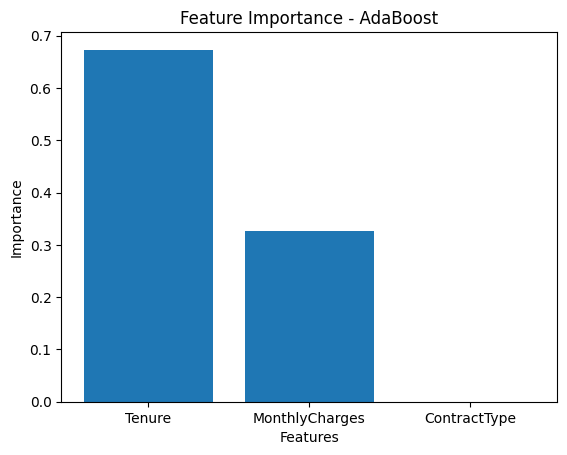

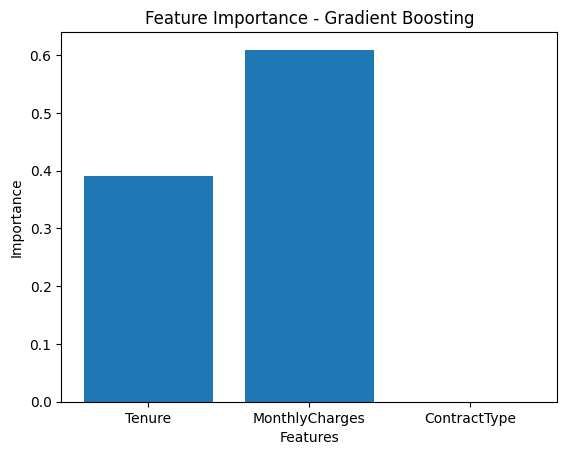

In [5]:

# SCENARIO 2 - BOOSTING (AdaBoost & Gradient Boosting)
from google.colab import files
uploaded = files.upload()
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, roc_curve, auc
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
print("Noorin Nashika M - 24BAD084")
print("Boosting Models - Customer Churn Prediction")

# LOAD DATASET
df = pd.read_csv("churn_boosting.csv")

print("\nFirst 5 rows:\n", df.head())

# PREPROCESSING

df = df[['Tenure', 'MonthlyCharges', 'ContractType', 'Churn']]

# Handle missing values
df.dropna(inplace=True)

# Encode categorical variables
le_contract = LabelEncoder()
df['ContractType'] = le_contract.fit_transform(df['ContractType'])

# Encode Churn if needed
if df['Churn'].dtype == 'object':
    le_churn = LabelEncoder()
    df['Churn'] = le_churn.fit_transform(df['Churn'])

# Features and target (ONLY ONCE - correct)
X = df[['Tenure', 'MonthlyCharges', 'ContractType']]
y = df['Churn']

# TRAIN-TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# MODEL 1: AdaBoost

ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(X_train, y_train)

y_pred_ada = ada.predict(X_test)
y_prob_ada = ada.predict_proba(X_test)[:, 1]

acc_ada = accuracy_score(y_test, y_pred_ada)

# MODEL 2: Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:, 1]

acc_gb = accuracy_score(y_test, y_pred_gb)


# PERFORMANCE COMPARISON

print("\nModel Accuracy:")
print(f"AdaBoost Accuracy: {acc_ada:.4f}")
print(f"Gradient Boosting Accuracy: {acc_gb:.4f}")

# ROC CURVE
fpr_ada, tpr_ada, _ = roc_curve(y_test, y_prob_ada)
roc_auc_ada = auc(fpr_ada, tpr_ada)

fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)
roc_auc_gb = auc(fpr_gb, tpr_gb)

plt.figure()
plt.plot(fpr_ada, tpr_ada, label=f"AdaBoost (AUC = {roc_auc_ada:.2f})")
plt.plot(fpr_gb, tpr_gb, label=f"Gradient Boosting (AUC = {roc_auc_gb:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Boosting Models")
plt.legend()
plt.show()

# FEATURE IMPORTANCE

features = X.columns

# AdaBoost Feature Importance
plt.figure()
plt.bar(features, ada.feature_importances_)
plt.title("Feature Importance - AdaBoost")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

# Gradient Boosting Feature Importance
plt.figure()
plt.bar(features, gb.feature_importances_)
plt.title("Feature Importance - Gradient Boosting")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

Saving income_random_forest.csv to income_random_forest (1).csv
Noorin Nashika M - 24BAD084
Random Forest - Income Prediction

First 5 rows:
    Age  EducationYears  HoursPerWeek  Experience  Income
0   37              12            44          12       0
1   46              19            58          33       1
2   53              10            54          24       0
3   46              11            22           6       0
4   36              17            56           3       1

Accuracy (100 trees): 1.0000


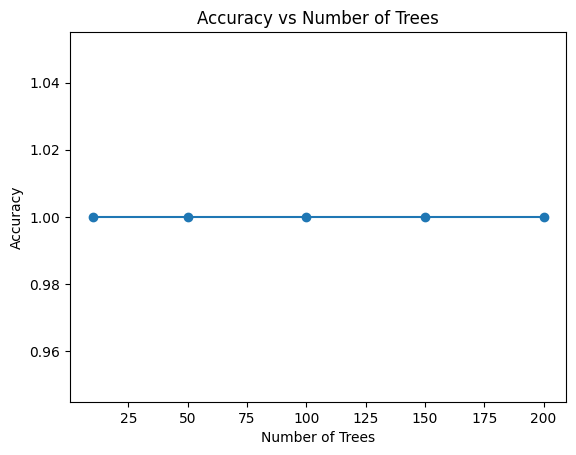

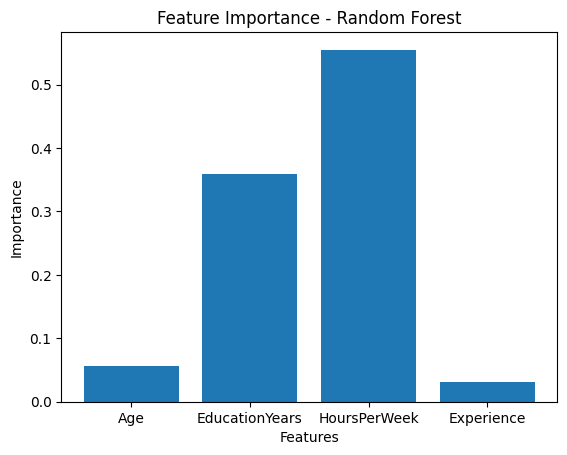

In [7]:

# SCENARIO 3 - RANDOM FOREST
from google.colab import files
uploaded = files.upload()
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
print("Noorin Nashika M - 24BAD084")
print("Random Forest - Income Prediction")

# LOAD DATASET
df = pd.read_csv("income_random_forest.csv")

print("\nFirst 5 rows:\n", df.head())

# PREPROCESSING

# Select correct columns (based on YOUR dataset)
df = df[['Age', 'EducationYears', 'HoursPerWeek', 'Experience', 'Income']]

# Drop missing values
df.dropna(inplace=True)

# Features & Target
X = df[['Age', 'EducationYears', 'HoursPerWeek', 'Experience']]
y = df['Income']

# TRAIN-TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TRAIN RANDOM FOREST
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"\nAccuracy (100 trees): {acc:.4f}")

# TUNE NUMBER OF TREES

trees = [10, 50, 100, 150, 200]
accuracies = []

for n in trees:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)

    y_pred_temp = model.predict(X_test)
    acc_temp = accuracy_score(y_test, y_pred_temp)

    accuracies.append(acc_temp)

# PLOT: Accuracy vs Trees

plt.figure()
plt.plot(trees, accuracies, marker='o')
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Number of Trees")
plt.show()

# FEATURE IMPORTANCE
importance = rf.feature_importances_
features = X.columns

plt.figure()
plt.bar(features, importance)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance - Random Forest")
plt.show()

Saving heart_stacking.csv to heart_stacking (1).csv
Noorin Nashika M - 24BAD084
Stacking - Heart Disease Prediction

First 5 rows:
    Age  Cholesterol  MaxHeartRate  RestingBP  HeartDisease
0   57          212           189        118             0
1   44          266           155        146             1
2   59          279           168        128             1
3   66          237           123        145             1
4   58          221           125        132             0

Model Accuracies:
Logistic Regression: 0.7083
SVM: 0.7917
Decision Tree: 0.6250
Stacking: 0.7500


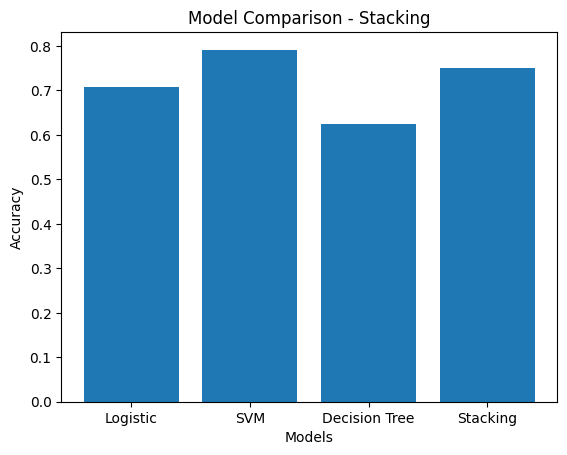

In [9]:

# SCENARIO 4 - STACKING
from google.colab import files
uploaded = files.upload()
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import StackingClassifier
print("Noorin Nashika M - 24BAD084")
print("Stacking - Heart Disease Prediction")

# LOAD DATASET
df = pd.read_csv("heart_stacking.csv")

print("\nFirst 5 rows:\n", df.head())

# PREPROCESSING

# Correct column names
df = df[['Age', 'Cholesterol', 'MaxHeartRate', 'HeartDisease']]

# Drop missing values
df.dropna(inplace=True)

# Features & Target
X = df[['Age', 'Cholesterol', 'MaxHeartRate']]
y = df['HeartDisease']

# TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# FEATURE SCALING
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# BASE MODELS
lr = LogisticRegression()
svm = SVC(probability=True)
dt = DecisionTreeClassifier(random_state=42)

# Train models
lr.fit(X_train, y_train)
svm.fit(X_train, y_train)
dt.fit(X_train, y_train)

# Accuracy
acc_lr = accuracy_score(y_test, lr.predict(X_test))
acc_svm = accuracy_score(y_test, svm.predict(X_test))
acc_dt = accuracy_score(y_test, dt.predict(X_test))

# STACKING MODEL

estimators = [
    ('lr', LogisticRegression()),
    ('svm', SVC(probability=True)),
    ('dt', DecisionTreeClassifier())
]

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression()
)

stack.fit(X_train, y_train)
acc_stack = accuracy_score(y_test, stack.predict(X_test))

# RESULTS

print("\nModel Accuracies:")
print(f"Logistic Regression: {acc_lr:.4f}")
print(f"SVM: {acc_svm:.4f}")
print(f"Decision Tree: {acc_dt:.4f}")
print(f"Stacking: {acc_stack:.4f}")

# BAR CHART
models = ['Logistic', 'SVM', 'Decision Tree', 'Stacking']
accuracies = [acc_lr, acc_svm, acc_dt, acc_stack]

plt.figure()
plt.bar(models, accuracies)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison - Stacking")
plt.show()

Saving fraud_smote.csv to fraud_smote (1).csv
Noorin Nashika M - 24BAD084
SMOTE - Fraud Detection

First 5 rows:
     Amount   Time  Feature1  Feature2  Fraud
0  3233.38  34595  2.157308 -0.818199      0
1  2783.63  73166  1.561511  0.955305      0
2   923.74  84417 -0.027305 -1.418366      0
3  2214.14  11139 -0.643518 -0.466037      0
4   444.75  37847  0.021272 -0.529053      0

Class Distribution BEFORE SMOTE:
Fraud
0    110
1     10
Name: count, dtype: int64


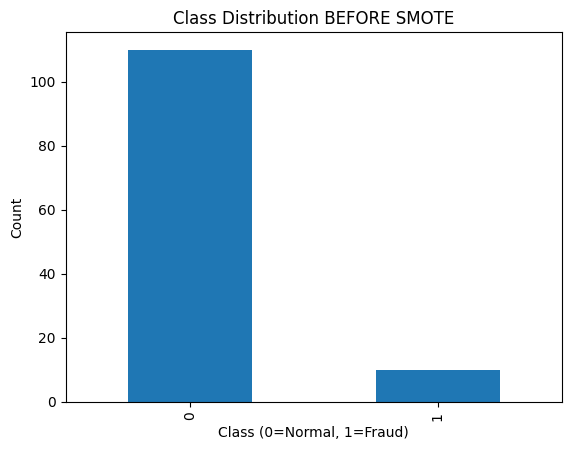


Class Distribution AFTER SMOTE:
Fraud
1    88
0    88
Name: count, dtype: int64


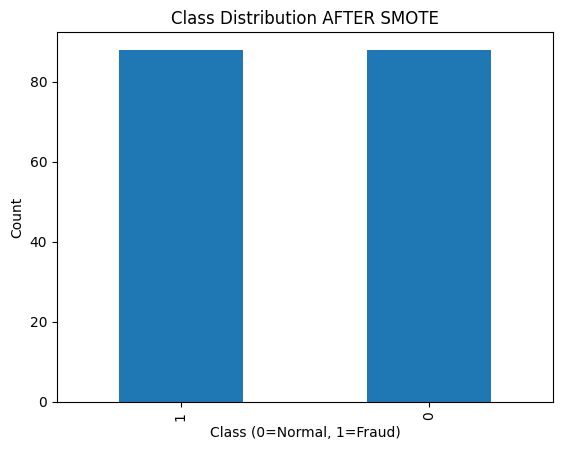


Accuracy Comparison:
Before SMOTE: 0.9167
After SMOTE: 0.8333


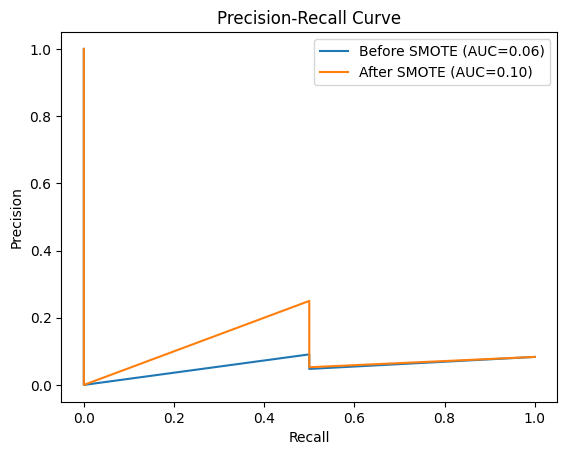

In [11]:

# SCENARIO 5 - SMOTE (Fraud Detection)
from google.colab import files
uploaded = files.upload()
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_curve, auc

from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
print("Noorin Nashika M - 24BAD084")
print("SMOTE - Fraud Detection")

# LOAD DATASET
df = pd.read_csv("fraud_smote.csv")

print("\nFirst 5 rows:\n", df.head())

# CHECK CLASS IMBALANCE
print("\nClass Distribution BEFORE SMOTE:")
print(df['Fraud'].value_counts())

# Plot BEFORE SMOTE
plt.figure()
df['Fraud'].value_counts().plot(kind='bar')
plt.title("Class Distribution BEFORE SMOTE")
plt.xlabel("Class (0=Normal, 1=Fraud)")
plt.ylabel("Count")
plt.show()

# FEATURES & TARGET
# Assuming dataset already numeric (Time, Amount, PCA features)
X = df.drop('Fraud', axis=1)
y = df['Fraud']

# TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# MODEL BEFORE SMOTE
model_before = RandomForestClassifier(random_state=42)
model_before.fit(X_train, y_train)

y_pred_before = model_before.predict(X_test)
y_prob_before = model_before.predict_proba(X_test)[:, 1]

acc_before = accuracy_score(y_test, y_pred_before)

# APPLY SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("\nClass Distribution AFTER SMOTE:")
print(pd.Series(y_train_sm).value_counts())

# Plot AFTER SMOTE
plt.figure()
pd.Series(y_train_sm).value_counts().plot(kind='bar')
plt.title("Class Distribution AFTER SMOTE")
plt.xlabel("Class (0=Normal, 1=Fraud)")
plt.ylabel("Count")
plt.show()

# MODEL AFTER SMOTE
model_after = RandomForestClassifier(random_state=42)
model_after.fit(X_train_sm, y_train_sm)

y_pred_after = model_after.predict(X_test)
y_prob_after = model_after.predict_proba(X_test)[:, 1]

acc_after = accuracy_score(y_test, y_pred_after)

# PERFORMANCE COMPARISON

print("\nAccuracy Comparison:")
print(f"Before SMOTE: {acc_before:.4f}")
print(f"After SMOTE: {acc_after:.4f}")

# PRECISION-RECALL CURVE
prec_before, rec_before, _ = precision_recall_curve(y_test, y_prob_before)
pr_auc_before = auc(rec_before, prec_before)

prec_after, rec_after, _ = precision_recall_curve(y_test, y_prob_after)
pr_auc_after = auc(rec_after, prec_after)

plt.figure()
plt.plot(rec_before, prec_before, label=f"Before SMOTE (AUC={pr_auc_before:.2f})")
plt.plot(rec_after, prec_after, label=f"After SMOTE (AUC={pr_auc_after:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()